# Week 7 — LLM Feature Extraction for M&A Prediction

**Goal:** Test whether a generative LLM (via OpenRouter, `gpt-4o-mini` / `gpt-4o`) can read a company's
pre-announcement news and extract *strategic-intent* signals — "exploring strategic
alternatives," activist pressure, management turnover, distress — that beat the week-4
classic-NLP stack at predicting M&A.

### Pipeline
```
ma_event_news.csv        ->  extract_llm_features.py           ->  data/raw/llm/*.csv   ->  this notebook
(GDELT+EDGAR headlines,      1 structured-JSON call per            resumable, $-capped      feature sets A/B/C
 same cache as week4)        (event, window): 17 fields            per-call cache           -> same models as week4
```

- **Feature set A** — the week-4 classic-NLP stack (VADER, FinBERT, log-odds terms, NMF
  topics, momentum, EDGAR filing mix), recomputed in this notebook **on the exact same
  scraped corpus** the LLM reads.
- **Feature set B** — the 12 numeric LLM signals per (event, window).
- **Feature set C** — A + B combined.

Same experimental design as week4: `pre` (label=1) = [announcement−97d, announcement−7d],
`baseline` (label=0) = same window shifted back 180d for the **same company** (paired design);
time-based 80/20 split; LogisticRegressionCV / Random Forest / Gradient Boosting.

### ⚠️ Three validity threats, each tested before results are trusted
| # | Threat | Where tested |
|---|--------|--------------|
| 1 | **Training-data look-ahead** — the LLM's training corpus contains news about most of these 2016–2025 deals; it may "remember" outcomes rather than read the text | §7a memorization probe (no news shown), §7b company-name-masking A/B, post-knowledge-cutoff holdout |
| 2 | **Score arbitrariness** — "activist_pressure = 7" is not a measurement; the same input can score differently on a re-run | §7c repeat-consistency (re-score the same windows, measure variance) |
| 3 | **Small-sample noise** — a few hundred test rows swing AUC by ±0.05+ | bootstrap 95% CIs on every reported AUC; paired Wilcoxon as primary evidence |

This notebook **never calls the OpenAI API** — it only loads the local caches written by
`code/extract_llm_features.py` (so teammates can run it with no API key). Each analysis cell
prints the CLI command to top up the cache it reads.

## 1. Setup & Data  (deck slides 2-3)
Imports and config, the ground-truth deals, and one deal traced end-to-end into its two labeled windows.

In [1]:
# Install the packages this notebook needs (idempotent, safe to re-run)
import subprocess, sys
for pkg in ['vaderSentiment', 'scikit-learn', 'transformers', 'torch', 'openai', 'python-dotenv']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)
print('✓ Dependencies ready')

✓ Dependencies ready


In [2]:
# Imports: stdlib, numpy/pandas/plotting, scikit-learn, scipy
import os, re, json, warnings, random, sys
from pathlib import Path
from datetime import timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import NMF
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
from scipy import stats as scipy_stats

# Plot styling and silence noisy library warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120})

# ── Paths ──────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path('..').resolve()
CODE_DIR     = PROJECT_ROOT / 'code'
EVENTS_PATH  = PROJECT_ROOT / 'data' / 'raw' / 'events' / 'ma_events.csv'
NEWS_CACHE   = PROJECT_ROOT / 'data' / 'raw' / 'news' / 'ma_event_news.csv'      # download_news_ma_events.py
LLM_SCORES   = PROJECT_ROOT / 'data' / 'raw' / 'llm' / 'ma_event_llm_scores.csv' # extract_llm_features.py
LLM_PROBE    = PROJECT_ROOT / 'data' / 'raw' / 'llm' / 'ma_event_llm_probe.csv'
FEATURES_A_OUT   = PROJECT_ROOT / 'data' / 'interim' / 'ma_news_features_week7.csv'
LLM_FEATURES_OUT = PROJECT_ROOT / 'data' / 'interim' / 'ma_llm_features.csv'
OUT_DIR      = PROJECT_ROOT / 'outputs' / 'week7'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Reuse the exact same helpers/constants as the scraper + LLM scorer (no drift)
sys.path.insert(0, str(CODE_DIR))
from download_news_ma_events import clean_name, get_window_dates
from extract_llm_features import (NOISE_RE, JUNK_DOMAINS, PROMPT_VERSION, SCORE_FIELDS,
                                  SIGNAL_FIELDS_0_10, MODEL_KNOWLEDGE_CUTOFF, FTYPE_RE)

# ── Experiment config (must match the scraping + extraction runs) ─────────
LOOKBACK_DAYS   = 90
BLACKOUT_DAYS   = 7
NEGATIVE_SHIFT  = 180
RANDOM_SEED     = 42
N_TOPICS        = 8
PRIMARY_MODEL   = 'openai/gpt-4o-mini'
SENSITIVITY_MODEL = 'openai/gpt-4o'

LLM_NUMERIC = [f'llm_{f}' for f in SCORE_FIELDS]   # the 12 numeric LLM fields
DECK = {}                                          # stats collected for the deck (§10)

# Fix every RNG seed so splits, models, and bootstraps reproduce exactly
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print('✓ Imports complete — this notebook makes NO API calls (loads local caches only)')

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Imports complete — this notebook makes NO API calls (loads local caches only)


In [3]:
# Load ground-truth deals and the local news cache
events = pd.read_csv(EVENTS_PATH, parse_dates=['announcement_date', 'close_date'])
news_df = pd.read_csv(NEWS_CACHE, dtype=str).fillna('')

# Report cache coverage: events, articles, and news sources
print(f'M&A events (≥$1B, 2016-2026):   {len(events):>8,}')
print(f'Date range:                     {events["announcement_date"].min().date()} → {events["announcement_date"].max().date()}')
print(f'\nLocal news cache: {len(news_df):,} rows, {news_df["transaction_id"].nunique()} events')
articles_only = news_df[news_df['title'] != '']
print(f'  Articles with text:     {len(articles_only):,}')
print(f'  Events with ≥1 article: {articles_only["transaction_id"].nunique()}')
print(f'  By source:              {articles_only["source"].value_counts().to_dict()}')

# Stash raw counts for the deck
DECK['n_events_total'] = int(len(events))
DECK['n_events_cached'] = int(news_df['transaction_id'].nunique())
DECK['n_articles_cached'] = int(len(articles_only))

M&A events (≥$1B, 2016-2026):      2,673
Date range:                     2016-06-24 → 2026-06-16

Local news cache: 41,256 rows, 1801 events
  Articles with text:     39,664
  Events with ≥1 article: 1162
  By source:              {'gdelt': 23019, 'edgar': 16645}


In [4]:
# ── One event, traced end to end: how a deal becomes two labeled rows ───────
# Deterministic pick: the cached event with the most GDELT coverage in BOTH windows.
# Pick the best-covered cached event (most GDELT headlines in both windows)
gd = news_df[(news_df['source'] == 'gdelt') & (news_df['title'] != '')]
cnt = gd.groupby(['transaction_id', 'window']).size().unstack(fill_value=0)
ok_cov = cnt[(cnt.get('pre', 0) >= 3) & (cnt.get('baseline', 0) >= 3)]
demo_txn = (ok_cov['pre'] + ok_cov['baseline']).idxmax() if len(ok_cov) else cnt.sum(axis=1).idxmax()
ev = events[events['transaction_id'] == demo_txn].iloc[0]

# Layer 1: the real deal is one row in ma_events.csv (the label source)
print('LAYER 1 — ground truth (ma_events.csv): one row per real deal — the LABEL source')
print(f"  {ev.transaction_id}: {ev.target_name}  <—  {ev.acquirer_name}")
print(f"  announced {ev.announcement_date.date()} | ${ev.deal_value_usd / 1e9:.1f}B | {ev.primary_industry}")

print('\nLAYER 2 — news cache (ma_event_news.csv): the same deal as two labeled windows')
# Layer 2: the same deal split into two dated windows (pre=1, baseline=0)
for window, label in [('baseline', 0), ('pre', 1)]:
    start, end = get_window_dates(ev.announcement_date, window,
                                  LOOKBACK_DAYS, BLACKOUT_DAYS, NEGATIVE_SHIFT)
    w = gd[(gd['transaction_id'] == demo_txn) & (gd['window'] == window)]
    print(f"\n  window={window!r} → label={label}    [{start} .. {end}]    ({len(w)} GDELT headlines)")
    for _, r in w.head(4).iterrows():
        print(f"    [{r['date'][:8]}] {r['title'][:84]}")
    if len(w) > 4:
        print(f"    ... +{len(w) - 4} more")

# Takeaway: the label is the calendar window, never the text
print('\nThe label comes ONLY from the calendar — which window a headline falls in relative to')
print('the announcement date. The text is only ever features. Note how much of the "coverage"')
print('is name-match noise: whether real deal chatter lands in the right window is the whole game.')

LAYER 1 — ground truth (ma_events.csv): one row per real deal — the LABEL source
  SPTRD1789404: Crunchyroll, Inc.  <—  Funimation Global Group, LLC
  announced 2020-12-09 | $1.2B | Movies and Entertainment

LAYER 2 — news cache (ma_event_news.csv): the same deal as two labeled windows

  window='baseline' → label=0    [2020-03-07 .. 2020-06-05]    (50 GDELT headlines)
    [20200606]   The 8th son ? Are you kidding me ? Reveals An Underwear Summoner Anime Clip
    [20200606] What On The Crunchyroll , Funimation , & HIDIVE Anime Streaming Calendar For June 6t
    [20200606] Crunchyroll - Sound ! Euphonium Marches on With 5th Anniversary Project Celebrating 
    [20200606] 10th  Princess Connect ! Re : Dive  Anime Episode Previewed
    ... +46 more

  window='pre' → label=1    [2020-09-03 .. 2020-12-02]    (50 GDELT headlines)
    [20201203] HBO Max : Everything about the app set to stream Wonder Woman 1984 , Matrix 4 and Du
    [20201203] Crunchyroll Releases Princess Connect ! Re : Div

## 2. What We Send the LLM  (deck slides 4-5)
One structured JSON call per (event, window). Load the score cache, then print the exact prompt and response for one real window.

In [5]:
# ── Load the LLM score cache; parse numeric features ────────────────────────
# Prefer the raw per-call cache; fall back to the committed parsed matrix so the
# notebook runs from a fresh clone with no API key (data/raw/llm/ is gitignored).
if LLM_SCORES.exists():
    _llm_src = LLM_SCORES
elif LLM_FEATURES_OUT.exists():
    _llm_src = LLM_FEATURES_OUT
else:
    raise RuntimeError('No LLM scores. Run: python code/extract_llm_features.py '
                       '(or use the committed data/interim/ma_llm_features.csv).')
# Load cache; keep parsed-OK rows only, last write wins per resume key
llm_raw = pd.read_csv(_llm_src, dtype=str).fillna('')
ok = llm_raw[llm_raw['parse_ok'] == '1'].copy()
# last write wins per resume key (failed earlier attempts may precede a success)
ok = ok.drop_duplicates(subset=['transaction_id', 'window', 'task', 'model',
                                'prompt_version', 'variant', 'run_tag'], keep='last')
# Coerce the numeric feature, cost, and label columns
for c in LLM_NUMERIC:
    ok[c] = pd.to_numeric(ok[c], errors='coerce')
ok['cost_usd'] = pd.to_numeric(ok['cost_usd'], errors='coerce').fillna(0.0)
ok['label_int'] = pd.to_numeric(ok['label'], errors='coerce')

# Coverage table: windows / events / cost per run
print('LLM cache coverage (rows scored ok, by run):')
cov = ok.groupby(['task', 'model', 'variant', 'run_tag']).agg(
    windows=('transaction_id', 'size'), events=('transaction_id', 'nunique'),
    cost_usd=('cost_usd', 'sum')).round(3)
print(cov.to_string())

# Report failed calls and total spend / token usage
fail = llm_raw[llm_raw['parse_ok'] != '1']
print(f'\nFailed/refused calls (retryable): {len(fail)}')
total_cost = ok['cost_usd'].sum() + pd.to_numeric(fail['cost_usd'], errors='coerce').fillna(0).sum()
in_tok  = pd.to_numeric(llm_raw['input_tokens'], errors='coerce').fillna(0).sum()
out_tok = pd.to_numeric(llm_raw['output_tokens'], errors='coerce').fillna(0).sum()
print(f'Total spend in this cache: ${total_cost:.2f}  ({in_tok:,.0f} input + {out_tok:,.0f} output tokens)')

# Committed derived matrix so teammates can run this notebook with no API key:
# Save the parsed matrix so teammates can run this notebook keyless
ok.drop(columns=['json_raw'], errors='ignore').to_csv(LLM_FEATURES_OUT, index=False)
print(f'Parsed matrix -> {LLM_FEATURES_OUT.relative_to(PROJECT_ROOT)}')

# Stash cost/token stats for the deck
DECK['llm_total_cost'] = float(round(total_cost, 2))
DECK['llm_calls_ok'] = int(len(ok))
DECK['llm_tokens'] = int(in_tok + out_tok)

LLM cache coverage (rows scored ok, by run):
                                             windows  events  cost_usd
task    model              variant  run_tag                           
day0    gpt-5-mini         unmasked r1            11      11     0.010
extract gpt-5              unmasked r1            65      37     0.215
        gpt-5-mini         masked   r1            65      37     0.050
                           unmasked r1            65      37     0.050
                                    r2            44      25     0.033
        openai/gpt-4o      unmasked r1           143      82     0.644
        openai/gpt-4o-mini masked   r1          2002    1156     0.542
                           unmasked r1          2002    1156     0.542
                                    r2            53      32     0.013

Failed/refused calls (retryable): 1119
Total spend in this cache: $2.10  (5,331,074 input + 689,832 output tokens)
Parsed matrix -> data/interim/ma_llm_features.csv


In [6]:
# ── Transparency: the EXACT prompt for one real window + what came back ────
# Import the exact prompt-builders the scorer uses (guarantees no drift)
from extract_llm_features import (build_window_corpus, pack_headlines,
                                  build_messages_extract, edgar_summary_line)
# Pick one real, well-covered pre-window to display end-to-end
main = ok[(ok.task == 'extract') & (ok.model == PRIMARY_MODEL) &
          (ok.variant == 'unmasked') & (ok.run_tag == 'r1')]
# pick a pre-window with substantive coverage
demo = main[(main.window == 'pre') & (main.llm_headline_information_quality >= 5)]
demo = (demo.sort_values('llm_acquisition_likelihood', ascending=False).iloc[0]
        if len(demo) else main.iloc[0])
# Rebuild the exact system + user messages sent for that window
corpus = build_window_corpus(news_df[news_df.transaction_id == demo.transaction_id], events)
item = corpus[(demo.transaction_id, demo.window)]
lines, n_total = pack_headlines(item['gdelt'], 60, None)
msgs = build_messages_extract(item['company_name'], item['window_end_month'],
                              item['period_days'], lines, n_total,
                              edgar_summary_line(item['edgar_types']), False)
print('═' * 100)
# Print exactly what the model received
print(f"WHAT WE SEND — {demo.company_name!r}, window={demo.window} (label={demo.label})")
print('═' * 100)
for m in msgs:
    print(f"\n[{m['role'].upper()}]\n{m['content'][:2600]}")
print('\n' + '═' * 100)
# Print the strict-JSON response it returned
print('WHAT COMES BACK (strict JSON, one call):')
print('═' * 100)
demo_json = json.loads(demo.json_raw)
print(json.dumps(demo_json, indent=2)[:1800])
# Feed a trimmed copy of this real example to the deck
DECK['example_company'] = str(demo.company_name)
DECK['example_window'] = str(demo.window)
# Feed the REAL prompt/response to the deck (slide 4), truncated to fit its panels
user_lines = msgs[1]['content'].split('\n')
DECK['example_prompt_lines'] = [l[:62] for l in user_lines[:5] + user_lines[5:16]][:16]
resp_keep = ['ma_rumor_intensity', 'strategic_alternatives_review', 'activist_pressure',
             'management_instability', 'financial_distress', 'acquisition_likelihood',
             'dominant_theme', 'recognized_company', 'recognized_deal']
resp_small = {k: demo_json[k] for k in resp_keep if k in demo_json}
resp_small['evidence_quotes'] = [q[:48] + '…' for q in (demo_json.get('evidence_quotes') or [])[:2]]
resp_small['rationale'] = (demo_json.get('rationale') or '')[:110] + '…'
DECK['example_response_lines'] = [l[:60] for l in json.dumps(resp_small, indent=1).split('\n')][:18]

════════════════════════════════════════════════════════════════════════════════════════════════════
WHAT WE SEND — 'ANSYS, Inc.', window=pre (label=1)
════════════════════════════════════════════════════════════════════════════════════════════════════

[SYSTEM]
You are a financial-news analyst scoring M&A-precursor signals for ONE US public company from a single ~90-day period of its news coverage. Judge ONLY from the text provided. Do not use any memory of real-world outcomes for this specific company. Score each dimension 0-10 where 0 = no evidence in the text and 10 = overwhelming evidence. Be conservative: for most companies in most periods, most dimensions score 0-2. Quote only text that actually appears in the headlines.

[USER]
Company: ANSYS
Period: ~90 days ending 2024-01
SEC filings during the period: 8-K x3

Headlines (40 of 40 kept after spam filtering, chronological; [dNN] = day within the period, higher = later):
[d72] S & P 500 Gains and Losses Today : Nike Warns of Sof

In [7]:
# The main analysis run: openai/gpt-4o-mini, unmasked, first pass
llm_main = main.copy()   # openai/gpt-4o-mini · unmasked · r1 · task=extract
print(f'Main LLM run: {len(llm_main)} windows, {llm_main.transaction_id.nunique()} events')


Main LLM run: 2002 windows, 1156 events


## 3. Feature Set A: the classic-NLP baseline  (supports deck slide 6)
The week-4 stack, loaded here for the comparison; full construction is in Appendix A1.

In [8]:
# Feature set A = the week-4 classic-NLP stack (VADER, FinBERT, NMF topics, log-odds
# terms, momentum, EDGAR structure), recomputed on this corpus. Its full construction
# lives in Appendix A1; here we load the committed matrix so the modeling flow stays clean.
feat_df = pd.read_csv(FEATURES_A_OUT, parse_dates=['announcement_date'])
feat_df['has_news'] = feat_df['has_news'].astype(bool)
print(f'Feature set A loaded: {feat_df.shape}  ({feat_df.transaction_id.nunique()} events, '
      f'{int(feat_df.has_news.sum())} windows with coverage)')

Feature set A loaded: (3602, 35)  (1801 events, 2002 windows with coverage)


## 4. Results: Classic NLP vs LLM vs Combined  (deck slide 6)
Identical rows, one 80/20 time split. Feature sets A, B, C across three models, with bootstrap 95% CIs.

In [9]:
# ── Modeling frame: A ⋈ B on identical (transaction_id, window) rows ───────
# Join A + B on identical rows; encode industry as a feature
model_frame = feat_df[feat_df.has_news].merge(
    llm_main[['transaction_id', 'window'] + LLM_NUMERIC],
    on=['transaction_id', 'window'], how='inner')
le = LabelEncoder()
model_frame['industry_enc'] = le.fit_transform(model_frame['primary_industry'].fillna('Unknown'))

# Define the three feature sets: A (classic), B (LLM), C (both)
FEATURES_A = ['news_count', 'avg_sentiment', 'std_sentiment', 'pos_ratio', 'neg_ratio',
              'ma_keyword_count', 'ma_keyword_ratio', 'max_sentiment', 'min_sentiment',
              'avg_finbert_compound', 'std_finbert_compound', 'avg_finbert_positive',
              'avg_finbert_negative', 'distinctive_term_ratio', 'late_share',
              'sentiment_trend', 'edgar_filing_count', 'edgar_deal_filing_count',
              'edgar_deal_filing_ratio'] + [f'topic_{k}_mean' for k in range(N_TOPICS)] + ['industry_enc']
FEATURES_B = LLM_NUMERIC
FEATURES_C = FEATURES_A + FEATURES_B

# Time-based 80/20 split: train on older deals, test on newer
model_frame = model_frame.dropna(subset=['announcement_date']).sort_values('announcement_date')
split_date = model_frame['announcement_date'].quantile(0.80)
train = model_frame[model_frame.announcement_date <= split_date]
test  = model_frame[model_frame.announcement_date >  split_date]
y_train, y_test = train['label'].values, test['label'].values
# Report split sizes and class balance
print(f'Modeling rows: {len(model_frame)} ({model_frame.transaction_id.nunique()} events)')
print(f'Train: {len(train)} rows (≤ {split_date.date()})   Test: {len(test)} rows')
print(f'Class balance — train {y_train.mean():.1%} pos | test {y_test.mean():.1%} pos')

# Bootstrap a 95% CI for AUC (essential at this sample size)
def bootstrap_auc_ci(y, p, n_boot=1000, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    aucs = []
    y, p = np.asarray(y), np.asarray(p)
    for _ in range(n_boot):
        idx = rng.integers(0, len(y), len(y))
        if len(set(y[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y[idx], p[idx]))
    if not aucs:
        return float('nan'), float('nan')
    return float(np.percentile(aucs, 2.5)), float(np.percentile(aucs, 97.5))

# 5-fold CV used for model selection
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# Fit LogisticRegression / RandomForest / GradientBoosting for one set
def fit_feature_set(name, cols):
    Xtr_raw, Xte_raw = train[cols].fillna(0).values, test[cols].fillna(0).values
    used = list(cols)
    # keep the 16 most informative features (train-only mutual info)
    if len(cols) > 16:
        mi = mutual_info_classif(Xtr_raw, y_train, random_state=RANDOM_SEED)
        keep = np.argsort(mi)[::-1][:16]
        used = [cols[i] for i in keep]
        Xtr_raw, Xte_raw = train[used].fillna(0).values, test[used].fillna(0).values
    # standardize inputs for the linear model
    scaler = StandardScaler().fit(Xtr_raw)
    Xtr_s, Xte_s = scaler.transform(Xtr_raw), scaler.transform(Xte_raw)
    # three classifiers: scaled inputs for LR, raw for the trees
    models = {
        'Logistic Regression': (LogisticRegressionCV(Cs=np.logspace(-2, 1, 10), cv=cv,
                                max_iter=2000, scoring='roc_auc', random_state=RANDOM_SEED), Xtr_s, Xte_s),
        'Random Forest': (RandomForestClassifier(n_estimators=300, max_depth=4, min_samples_leaf=8,
                          class_weight='balanced', random_state=RANDOM_SEED), Xtr_raw, Xte_raw),
        'Gradient Boosting': (GradientBoostingClassifier(n_estimators=150, max_depth=2,
                              learning_rate=0.05, subsample=0.8, random_state=RANDOM_SEED), Xtr_raw, Xte_raw),
    }
    out = {}
    two_class_test = len(set(y_test)) > 1
    # fit each; record test AUC, bootstrap CI, and CV AUC
    for mname, (mdl, Xtr, Xte) in models.items():
        mdl.fit(Xtr, y_train)
        proba = mdl.predict_proba(Xte)[:, 1]
        lo, hi = bootstrap_auc_ci(y_test, proba) if two_class_test else (float('nan'), float('nan'))
        try:
            cv_auc = cross_val_score(mdl, Xtr, y_train, cv=cv, scoring='roc_auc').mean()
        except ValueError:
            cv_auc = float('nan')   # train split too small for 5-fold (tiny-cache dry runs)
        out[mname] = dict(model=mdl, proba=proba, used=used, cv_auc=cv_auc,
                          roc_auc=roc_auc_score(y_test, proba) if two_class_test else 0.5,
                          ci=(lo, hi),
                          pr_auc=average_precision_score(y_test, proba) if two_class_test else 0.5)
    return out

# Fit all three feature sets and print their AUCs
SETS = {'A: classic NLP (week4)': FEATURES_A, 'B: LLM signals only': FEATURES_B,
        'C: combined A+B': FEATURES_C}
results = {}
for sname, cols in SETS.items():
    results[sname] = fit_feature_set(sname, cols)
    print(f'\n{sname}  ({len(cols)} candidate features)')
    for mname, r in results[sname].items():
        print(f"  {mname:20s} CV {r['cv_auc']:.3f} | test ROC-AUC {r['roc_auc']:.3f} "
              f"[{r['ci'][0]:.3f}, {r['ci'][1]:.3f}] | PR-AUC {r['pr_auc']:.3f}")

Modeling rows: 2002 (1156 events)
Train: 1602 rows (≤ 2025-06-23)   Test: 400 rows
Class balance — train 51.6% pos | test 49.2% pos



A: classic NLP (week4)  (28 candidate features)
  Logistic Regression  CV 0.506 | test ROC-AUC 0.525 [0.470, 0.580] | PR-AUC 0.532
  Random Forest        CV 0.517 | test ROC-AUC 0.523 [0.472, 0.578] | PR-AUC 0.507
  Gradient Boosting    CV 0.515 | test ROC-AUC 0.499 [0.446, 0.557] | PR-AUC 0.500



B: LLM signals only  (12 candidate features)
  Logistic Regression  CV 0.504 | test ROC-AUC 0.518 [0.465, 0.571] | PR-AUC 0.520
  Random Forest        CV 0.557 | test ROC-AUC 0.517 [0.468, 0.569] | PR-AUC 0.513
  Gradient Boosting    CV 0.545 | test ROC-AUC 0.502 [0.450, 0.553] | PR-AUC 0.506



C: combined A+B  (40 candidate features)
  Logistic Regression  CV 0.520 | test ROC-AUC 0.551 [0.495, 0.606] | PR-AUC 0.554
  Random Forest        CV 0.518 | test ROC-AUC 0.531 [0.477, 0.585] | PR-AUC 0.536
  Gradient Boosting    CV 0.527 | test ROC-AUC 0.522 [0.472, 0.574] | PR-AUC 0.538


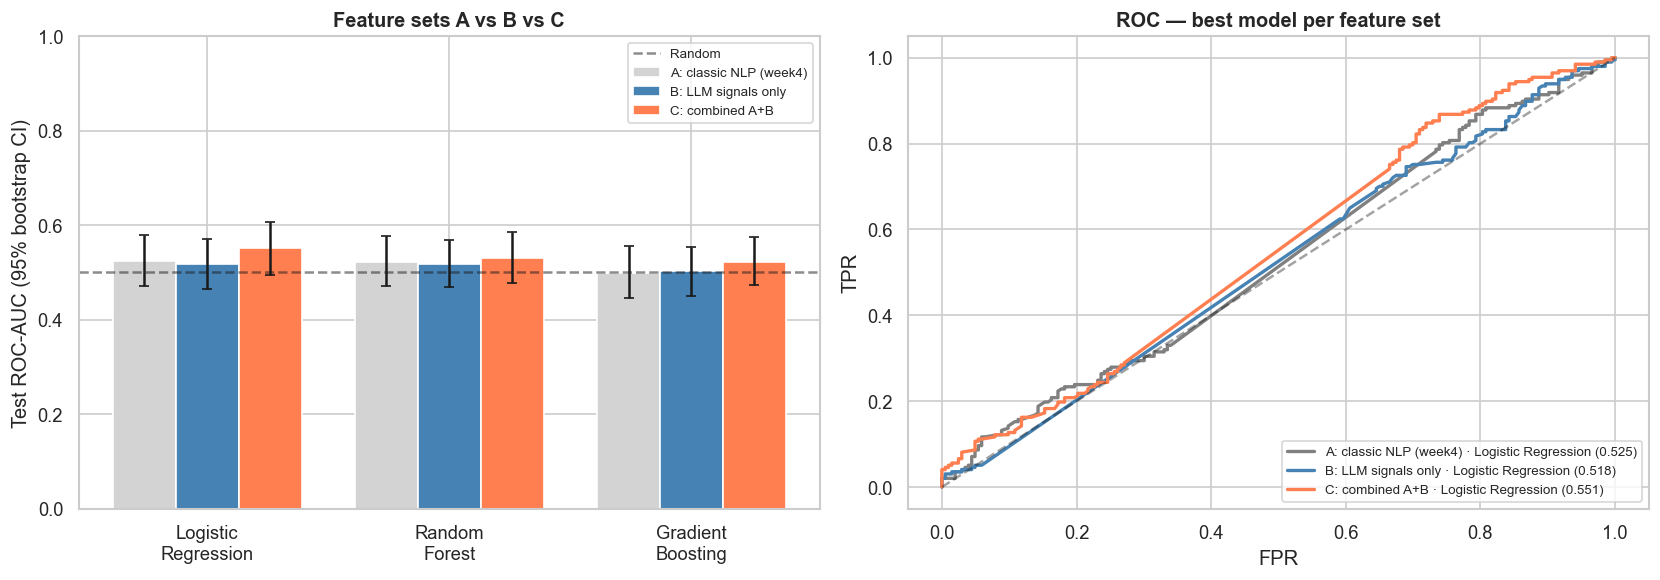

In [10]:
# ── Comparison chart + ROC overlay ──────────────────────────────────────────
# Left panel: grouped AUC bars with bootstrap CIs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
set_colors = {'A: classic NLP (week4)': 'lightgray', 'B: LLM signals only': 'steelblue',
              'C: combined A+B': 'coral'}
model_names = ['Logistic Regression', 'Random Forest', 'Gradient Boosting']
x = np.arange(len(model_names))
w = 0.26
for i, (sname, color) in enumerate(set_colors.items()):
    vals = [results[sname][m]['roc_auc'] for m in model_names]
    errs = np.array([[results[sname][m]['roc_auc'] - results[sname][m]['ci'][0] for m in model_names],
                     [results[sname][m]['ci'][1] - results[sname][m]['roc_auc'] for m in model_names]])
    axes[0].bar(x + (i - 1) * w, vals, w, yerr=errs, capsize=3, label=sname,
                color=color, edgecolor='white')
axes[0].axhline(0.5, color='k', linestyle='--', alpha=0.5, label='Random')
axes[0].set_xticks(x); axes[0].set_xticklabels([m.replace(' ', '\n') for m in model_names])
axes[0].set_ylim(0.0, 1.0); axes[0].set_ylabel('Test ROC-AUC (95% bootstrap CI)')
axes[0].set_title('Feature sets A vs B vs C', fontweight='bold'); axes[0].legend(fontsize=8)

# Right panel: ROC curve of the best model per feature set
for sname, color in [('A: classic NLP (week4)', 'gray'), ('B: LLM signals only', 'steelblue'),
                     ('C: combined A+B', 'coral')]:
    best = max(results[sname], key=lambda m: results[sname][m]['roc_auc'])
    fpr, tpr, _ = roc_curve(y_test, results[sname][best]['proba'])
    axes[1].plot(fpr, tpr, lw=2, color=color,
                 label=f"{sname} · {best} ({results[sname][best]['roc_auc']:.3f})")
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[1].set_title('ROC — best model per feature set', fontweight='bold')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig_auc_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

# Stash the full AUC table and split info for the deck
DECK['auc'] = {s: {m: dict(auc=round(r['roc_auc'], 3), lo=round(r['ci'][0], 3),
                           hi=round(r['ci'][1], 3), pr=round(r['pr_auc'], 3),
                           cv=round(r['cv_auc'], 3))
                   for m, r in ms.items()} for s, ms in results.items()}
DECK['n_model_rows'] = int(len(model_frame)); DECK['n_test_rows'] = int(len(test))
DECK['n_events_llm_scored'] = int(model_frame.transaction_id.nunique())
DECK['split_date'] = str(split_date.date())

## 5. Why the AUC Is Flat  (deck slide 7)
The signal case vs the inversion case, and each company's own pre-minus-baseline change.

In [11]:
# ── Two worked examples: the signal case vs the inversion case ──────────────
# Picked from the data, not hardcoded: the companies with the largest positive and
# largest negative (pre − baseline) gap in llm_acquisition_likelihood.
# Per-company pre vs baseline acquisition_likelihood
lik = llm_main.pivot_table(index='transaction_id', columns='window',
                           values='llm_acquisition_likelihood')
lik = (lik.dropna(subset=['pre', 'baseline'])
       if {'pre', 'baseline'}.issubset(lik.columns) else lik.iloc[0:0])
# Pick the biggest 'signal' case and the biggest 'inversion' case
if len(lik) >= 2:
    lik = lik.assign(diff=lik['pre'] - lik['baseline'])
    names = events.set_index('transaction_id')['target_name']
    show_fields = ['llm_ma_rumor_intensity', 'llm_strategic_alternatives_review',
                   'llm_financial_distress', 'llm_acquisition_likelihood', 'llm_dominant_theme']
    # Print both cases with the LLM's own evidence quotes
    for tag, txn in [('SIGNAL case — largest (pre − baseline) gap', lik['diff'].idxmax()),
                     ('INVERSION case — largest (baseline − pre) gap', lik['diff'].idxmin())]:
        sub = llm_main[llm_main.transaction_id == txn].sort_values('window')
        print('═' * 96)
        print(f"{tag}:  {names.get(txn, txn)}")
        print('═' * 96)
        print(sub[['window', 'label'] + show_fields].to_string(index=False))
        for _, r in sub.iterrows():
            for q in json.loads(r.llm_evidence_quotes or '[]')[:2]:
                print(f"   {r.window}-window evidence: “{q}”")
        print()
    # Takeaway: signals and inversions cancel, so the paired test comes out flat
    print('If run-up chatter reliably exceeded quiet-period chatter, the SIGNAL pattern would')
    print('dominate. The INVERSION case is why it does not: deal speculation lands in the')
    print('"quiet" window as often as the run-up (rumors about deals that came later, or never).')
else:
    print('Fewer than 2 complete pre/baseline pairs scored — top up the LLM cache first.')

════════════════════════════════════════════════════════════════════════════════════════════════
SIGNAL case — largest (pre − baseline) gap:  Domtar Corporation
════════════════════════════════════════════════════════════════════════════════════════════════
  window label  llm_ma_rumor_intensity  llm_strategic_alternatives_review  llm_financial_distress  llm_acquisition_likelihood llm_dominant_theme
baseline     0                       0                                  0                       0                           0              other
     pre     1                      10                                  0                       0                          90     ma_speculation
   pre-window evidence: “Domtar confirms merger talks with Paper Excellence”
   pre-window evidence: “Domtar shares surge after producer acknowledges talks with Paper Excellence”

════════════════════════════════════════════════════════════════════════════════════════════════
INVERSION case — largest (base

In [12]:
# ── What the paired test actually ranks: each company's own (pre − baseline) change ──
# Show each company's own pre-minus-baseline change
if len(lik):
    names = events.set_index('transaction_id')['target_name']
    disp = lik.sort_values('diff').copy()
    disp.index = [str(names.get(t, t))[:42] for t in disp.index]
    print(f'llm_acquisition_likelihood — one row per company ({len(disp)} complete pairs):')
    print(pd.concat([disp.head(5), disp.tail(5)])[['pre', 'baseline', 'diff']].to_string())
    # Count ups vs downs: the anatomy of why the paired test stays flat
    n_up = int((disp['diff'] > 0).sum())
    n_dn = int((disp['diff'] < 0).sum())
    n_zero = int((disp['diff'] == 0).sum())
    print(f'\n{n_up} companies scored HIGHER in their run-up window, {n_dn} scored LOWER, '
          f'{n_zero} unchanged (mostly 0-vs-0 quiet coverage).')
    print('The Wilcoxon drops the zeros, ranks the remaining changes by magnitude, and asks')
    print('whether the ups systematically outweigh the downs. When the largest moves point in')
    print('BOTH directions, the ranks balance and p stays large — the per-company anatomy of')
    print('the ns results above, and of the AUC ≈ 0.5 in §6.')

llm_acquisition_likelihood — one row per company (846 complete pairs):
window                                 pre  baseline  diff
Evoqua Water Technologies Corp.        0.0      80.0 -80.0
Signify Health, Inc.*                  0.0      80.0 -80.0
Asklepios BioPharmaceutical, Inc.*     4.0      80.0 -76.0
Select Medical Holdings Corporation*   0.0      75.0 -75.0
Calpine Corporation                    5.0      80.0 -75.0
Life Storage, Inc.                    80.0       0.0  80.0
Clearwater Analytics Holdings, Inc.*  85.0       5.0  80.0
ChampionX Corporation                 80.0       0.0  80.0
Two Harbors Investment Corp.          85.0       0.0  85.0
Domtar Corporation                    90.0       0.0  90.0

208 companies scored HIGHER in their run-up window, 222 scored LOWER, 416 unchanged (mostly 0-vs-0 quiet coverage).
The Wilcoxon drops the zeros, ranks the remaining changes by magnitude, and asks
whether the ups systematically outweigh the downs. When the largest moves point in

## 6. Are the LLM Signals New Information?  (deck slide 8)
Spearman correlation of every LLM signal against every classic-NLP feature.

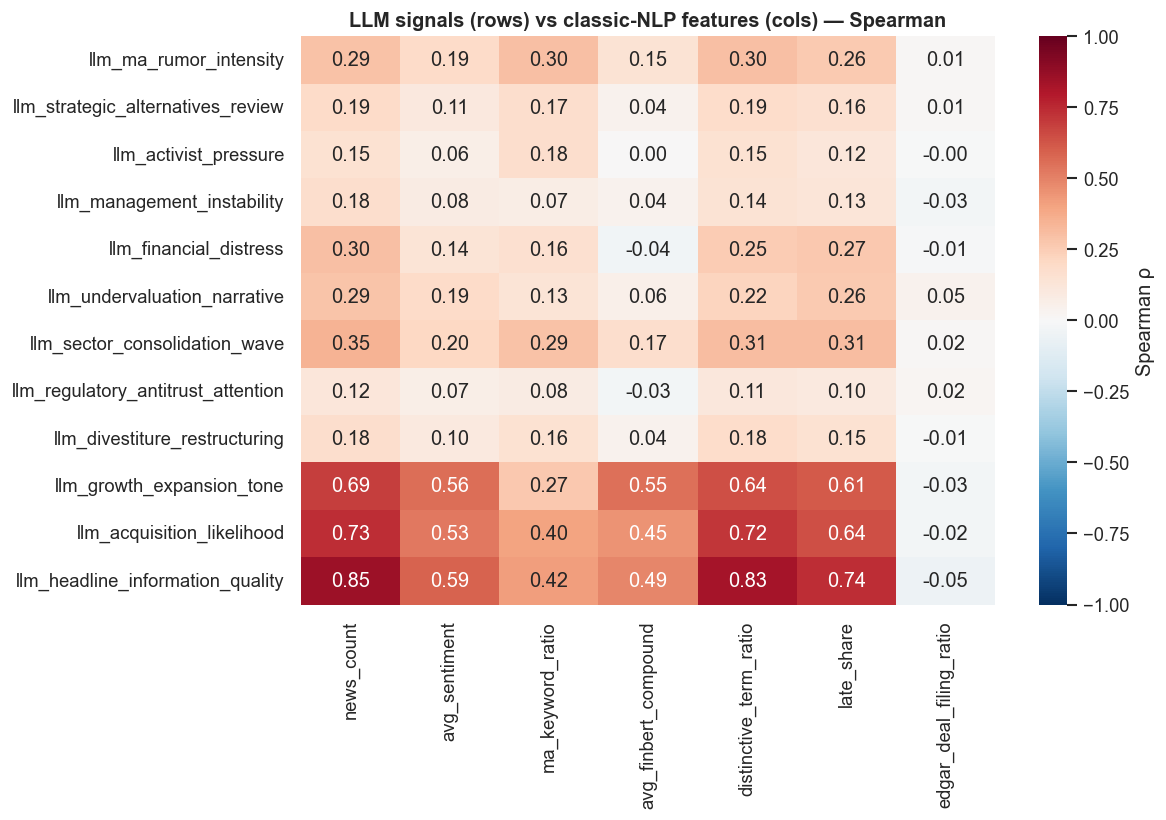

Max |ρ| between any LLM field and any classic feature: 0.85


In [13]:
# ── Redundancy check: are LLM signals just repackaged classic features? ─────
# Spearman-correlate every LLM signal with every classic feature
merged_eda = llm_main.merge(feat_df, on=['transaction_id', 'window'], how='inner', suffixes=('', '_A'))
a_cols = ['news_count', 'avg_sentiment', 'ma_keyword_ratio', 'avg_finbert_compound',
          'distinctive_term_ratio', 'late_share', 'edgar_deal_filing_ratio']
corr = pd.DataFrame({b: {a: scipy_stats.spearmanr(merged_eda[b], merged_eda[a])[0]
                         for a in a_cols} for b in LLM_NUMERIC}).T
# Heatmap: are the LLM signals just repackaged keyword features?
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            cbar_kws={'label': 'Spearman ρ'}, ax=ax)
ax.set_title('LLM signals (rows) vs classic-NLP features (cols) — Spearman', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig_llm_vs_classic_corr.png', dpi=200, bbox_inches='tight')
plt.show()
# Report the single strongest overlap
print(f'Max |ρ| between any LLM field and any classic feature: {corr.abs().max().max():.2f}')

## 7. Does the Model Already Know These Deals?  (deck slide 9)
The memorization probe: no news shown, answer from training memory alone.

In [14]:
# ── 7a. Memorization probe (no news shown; memory only) ────────────────────
# Load the memorization-probe cache (the no-news recall test)
if LLM_PROBE.exists():
    probe = pd.read_csv(LLM_PROBE, dtype=str).fillna('')
    probe = probe[probe.parse_ok == '1'].drop_duplicates(
        subset=['transaction_id', 'window', 'task', 'model', 'prompt_version', 'variant', 'run_tag'],
        keep='last')
    # Truth = real label; pred = model's yes/no; signed confidence
    probe['truth'] = pd.to_numeric(probe['label'], errors='coerce')
    probe['pred'] = (probe['probe_was_announced_target'] == '1').astype(int)
    probe['conf'] = pd.to_numeric(probe['probe_confidence_0_100'], errors='coerce').fillna(50)
    probe['conf_signed'] = np.where(probe['pred'] == 1, probe['conf'], -probe['conf'])
    # Check whether the model named the RIGHT acquirer (smoking-gun recall)
    probe = probe.merge(events[['transaction_id', 'announcement_date', 'acquirer_name']],
                        on='transaction_id', how='left')
    acq_norm = probe['acquirer_name'].fillna('').map(lambda s: clean_name(s).lower())
    guess_norm = probe['probe_acquirer_name_guess'].fillna('').map(lambda s: clean_name(s).lower())
    probe['acq_match'] = [bool(g) and bool(a) and (g in a or a in g or g.split()[0] == a.split()[0])
                          for g, a in zip(guess_norm, acq_norm)]

    # Per model: accuracy, acquirer precision, and pre- vs post-cutoff split
    DECK['probe'] = {}
    for model_name, g in probe.groupby('model'):
        acc = (g.pred == g.truth).mean()
        auc_conf = roc_auc_score(g.truth, g.conf_signed) if g.truth.nunique() > 1 else np.nan
        recall_claims = g[(g.truth == 1) & (g.probe_recalls_specific_deal == '1') &
                          (g.probe_acquirer_name_guess.str.strip() != '')]
        acq_prec = recall_claims['acq_match'].mean() if len(recall_claims) else np.nan
        # split by training-knowledge cutoff: memorizable vs unseen deals
        cutoff = pd.Timestamp(MODEL_KNOWLEDGE_CUTOFF.get(model_name, '2024-06-01'))
        pre_c  = g[g.announcement_date <  cutoff]
        post_c = g[g.announcement_date >= cutoff]
        acc_pre  = (pre_c.pred == pre_c.truth).mean() if len(pre_c) else np.nan
        acc_post = (post_c.pred == post_c.truth).mean() if len(post_c) else np.nan
        print(f'━━ {model_name} probe: n={len(g)} (balanced design, chance = 50%)')
        print(f'   accuracy {acc:.1%} | confidence-AUC {auc_conf:.3f}')
        print(f'   claims specific-deal recall on {len(recall_claims)} true positives; '
              f'acquirer named correctly in {acq_prec:.0%} of those' if len(recall_claims)
              else '   no specific-deal recall claims on true positives')
        print(f'   accuracy pre-cutoff (<{cutoff.date()}, memorizable): {acc_pre:.1%} | '
              f'post-cutoff (unseen): {acc_post:.1%}  [n={len(pre_c)}/{len(post_c)}]')
        DECK['probe'][model_name] = dict(n=int(len(g)), acc=round(float(acc), 3),
            auc_conf=round(float(auc_conf), 3) if pd.notna(auc_conf) else None,
            acq_precision=round(float(acq_prec), 3) if pd.notna(acq_prec) else None,
            n_recall_claims=int(len(recall_claims)),
            acc_pre_cutoff=round(float(acc_pre), 3) if pd.notna(acc_pre) else None,
            acc_post_cutoff=round(float(acc_post), 3) if pd.notna(acc_post) else None)
else:
    print('Probe cache missing. Run: python code/extract_llm_features.py --task probe')

━━ gpt-5-mini probe: n=118 (balanced design, chance = 50%)
   accuracy 51.7% | confidence-AUC 0.555
   claims specific-deal recall on 17 true positives; acquirer named correctly in 71% of those
   accuracy pre-cutoff (<2024-06-01, memorizable): 52.2% | post-cutoff (unseen): 50.0%  [n=90/28]
━━ openai/gpt-4o-mini probe: n=3602 (balanced design, chance = 50%)
   accuracy 50.4% | confidence-AUC 0.520
   claims specific-deal recall on 226 true positives; acquirer named correctly in 54% of those
   accuracy pre-cutoff (<2023-10-01, memorizable): 50.6% | post-cutoff (unseen): 50.1%  [n=1998/1604]


## 8. Masking & Repeatability  (deck slide 10)
Re-score with the company name hidden, and re-score the same window twice.

2002 windows scored both unmasked and masked
                             field  mean_unmasked  mean_masked  mean_shift  p_wilcoxon
            llm_ma_rumor_intensity          0.353        0.354      -0.001       0.701
 llm_strategic_alternatives_review          0.133        0.141      -0.007       0.615
             llm_activist_pressure          0.081        0.072       0.009       0.539
        llm_management_instability          0.066        0.076      -0.010       0.229
            llm_financial_distress          0.195        0.189       0.006       0.533
      llm_undervaluation_narrative          0.148        0.141       0.007       0.475
     llm_sector_consolidation_wave          0.312        0.294       0.018       0.451
llm_regulatory_antitrust_attention          0.043        0.041       0.001       0.510
     llm_divestiture_restructuring          0.118        0.104       0.014       0.236
         llm_growth_expansion_tone          1.426        1.468      -0.041       0.26

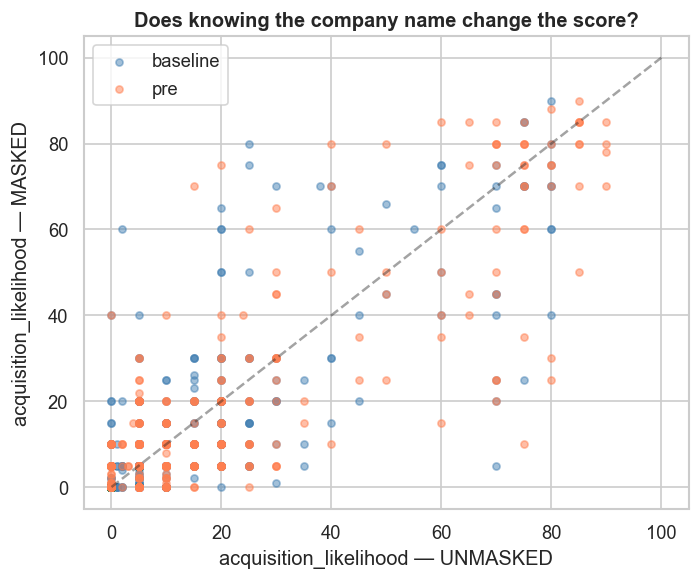

In [15]:
# ── 7b. Masked vs unmasked: how much do scores depend on knowing WHO it is? ──
# The same windows re-scored with the company name hidden
llm_masked = ok[(ok.task == 'extract') & (ok.model == PRIMARY_MODEL) &
                (ok.variant == 'masked') & (ok.run_tag == 'r1')]
if len(llm_masked):
    # Pair unmasked vs masked scores
    mm = llm_main.merge(llm_masked, on=['transaction_id', 'window'], suffixes=('_um', '_m'))
    print(f'{len(mm)} windows scored both unmasked and masked')
    rows = []
    for f in LLM_NUMERIC:
        # How much each field shifts when the name is removed
        d = mm[f'{f}_um'] - mm[f'{f}_m']
        p = scipy_stats.wilcoxon(d)[1] if (d != 0).sum() > 5 else np.nan
        rows.append(dict(field=f, mean_unmasked=mm[f'{f}_um'].mean(),
                         mean_masked=mm[f'{f}_m'].mean(), mean_shift=d.mean(), p_wilcoxon=p))
    mask_df = pd.DataFrame(rows)
    print(mask_df.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

    # ΔAUC: refit feature-set B using MASKED scores on the same rows/split
    # Refit feature-set B on masked scores to get a masked test AUC
    masked_frame = model_frame[['transaction_id', 'window', 'label', 'announcement_date']].merge(
        llm_masked[['transaction_id', 'window'] + LLM_NUMERIC], on=['transaction_id', 'window'])
    mtr = masked_frame[masked_frame.announcement_date <= split_date]
    mte = masked_frame[masked_frame.announcement_date >  split_date]
    if len(mte) > 10 and mte.label.nunique() > 1:
        gb = GradientBoostingClassifier(n_estimators=150, max_depth=2, learning_rate=0.05,
                                        subsample=0.8, random_state=RANDOM_SEED)
        gb.fit(mtr[LLM_NUMERIC].fillna(0), mtr.label)
        p_m = gb.predict_proba(mte[LLM_NUMERIC].fillna(0))[:, 1]
        auc_masked = roc_auc_score(mte.label, p_m)
        best_B = max(results['B: LLM signals only'],
                     key=lambda m: results['B: LLM signals only'][m]['roc_auc'])
        auc_unmasked = results['B: LLM signals only'][best_B]['roc_auc']
        print(f'\nFeature-set B test AUC — unmasked: {auc_unmasked:.3f} | masked: {auc_masked:.3f} '
              f'| Δ = {auc_unmasked - auc_masked:+.3f}')
        print('(a large positive Δ = the model was leaning on recognizing the company, not reading the text)')
        DECK['masking'] = dict(n=int(len(mm)), auc_unmasked=round(float(auc_unmasked), 3),
                               auc_masked=round(float(auc_masked), 3),
                               delta=round(float(auc_unmasked - auc_masked), 3))
    # Scatter: unmasked vs masked score for every window
    fig, ax = plt.subplots(figsize=(6, 5))
    for lbl, color, name in [(0, 'steelblue', 'baseline'), (1, 'coral', 'pre')]:
        sub = mm[pd.to_numeric(mm.label_um, errors='coerce') == lbl] if 'label_um' in mm else mm
        ax.scatter(sub['llm_acquisition_likelihood_um'], sub['llm_acquisition_likelihood_m'],
                   alpha=0.5, s=18, color=color, label=name)
    ax.plot([0, 100], [0, 100], 'k--', alpha=0.4)
    ax.set_xlabel('acquisition_likelihood — UNMASKED'); ax.set_ylabel('acquisition_likelihood — MASKED')
    ax.set_title('Does knowing the company name change the score?', fontweight='bold')
    ax.legend()
    plt.tight_layout(); plt.savefig(OUT_DIR / 'fig_masking.png', dpi=200, bbox_inches='tight'); plt.show()
else:
    print('No masked scores yet. Run: python code/extract_llm_features.py --mask-names')

53 windows scored twice (r1 vs r2, at default temperature, no seed, on these models)
                             field  spearman  mean_abs_diff
            llm_ma_rumor_intensity     1.000          0.094
 llm_strategic_alternatives_review       NaN          0.113
             llm_activist_pressure     1.000          0.000
        llm_management_instability     1.000          0.000
            llm_financial_distress       NaN          0.094
      llm_undervaluation_narrative       NaN          0.000
     llm_sector_consolidation_wave       NaN          0.208
llm_regulatory_antitrust_attention     1.000          0.019
     llm_divestiture_restructuring     0.490          0.151
         llm_growth_expansion_tone     0.901          0.283
        llm_acquisition_likelihood     0.861          1.585
  llm_headline_information_quality     0.963          0.415


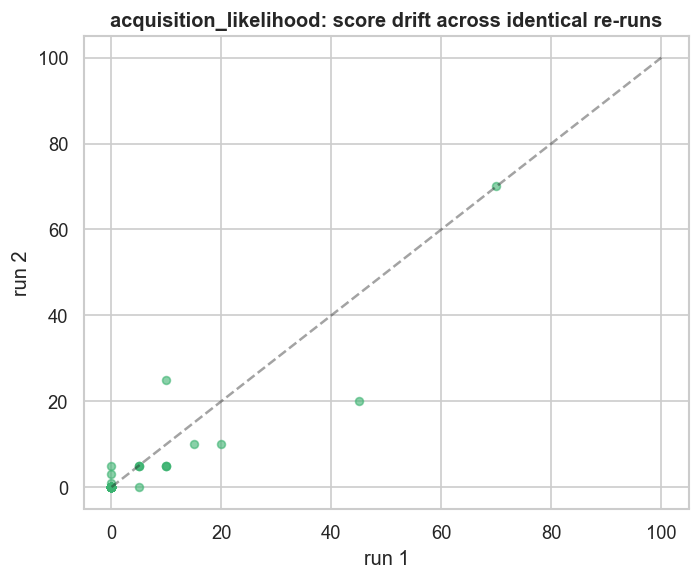

In [16]:
# ── 7c. Repeat consistency: same input, second run — how much do scores move? ──
# The second scoring pass on identical inputs (run 2)
r2 = ok[(ok.task == 'extract') & (ok.model == PRIMARY_MODEL) &
        (ok.variant == 'unmasked') & (ok.run_tag == 'r2')]
if len(r2):
    # Pair run-1 vs run-2 scores
    rr = llm_main.merge(r2, on=['transaction_id', 'window'], suffixes=('_1', '_2'))
    print(f'{len(rr)} windows scored twice (r1 vs r2, at default temperature, no seed, on these models)')
    rows = []
    for f in LLM_NUMERIC:
        # Per-field agreement (Spearman) and average point drift
        rho = scipy_stats.spearmanr(rr[f'{f}_1'], rr[f'{f}_2'])[0]
        rows.append(dict(field=f, spearman=rho, mean_abs_diff=(rr[f'{f}_1'] - rr[f'{f}_2']).abs().mean()))
    rep_df = pd.DataFrame(rows)
    print(rep_df.to_string(index=False, float_format=lambda x: f'{x:.3f}'))
    # Scatter: run-1 vs run-2 (how stable the scores are)
    lik = rr[['llm_acquisition_likelihood_1', 'llm_acquisition_likelihood_2']]
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(lik.iloc[:, 0], lik.iloc[:, 1], alpha=0.6, s=22, color='mediumseagreen')
    ax.plot([0, 100], [0, 100], 'k--', alpha=0.4)
    ax.set_xlabel('run 1'); ax.set_ylabel('run 2')
    ax.set_title('acquisition_likelihood: score drift across identical re-runs', fontweight='bold')
    plt.tight_layout(); plt.savefig(OUT_DIR / 'fig_repeat.png', dpi=200, bbox_inches='tight'); plt.show()
    DECK['repeat'] = dict(n=int(len(rr)),
                          mean_spearman=round(float(rep_df.spearman.mean()), 3),
                          likelihood_mean_abs_diff=round(float(
                              (lik.iloc[:, 0] - lik.iloc[:, 1]).abs().mean()), 2))
else:
    print('No r2 scores yet. Run: python code/extract_llm_features.py --repeat-tag r2 --limit-events 30')

## 9. Model Sensitivity & Cost  (deck slide 11)
openai/gpt-4o vs openai/gpt-4o-mini on the shared subset, and the cost per window.

In [17]:
# ── 7d. Model sensitivity: openai/gpt-4o vs openai/gpt-4o-mini on the nested subset ─────────
# The openai/gpt-4o subset (a costlier model scoring the same windows)
g5 = ok[(ok.task == 'extract') & (ok.model == SENSITIVITY_MODEL) &
        (ok.variant == 'unmasked') & (ok.run_tag == 'r1')]
if len(g5):
    # Pair openai/gpt-4o-mini vs openai/gpt-4o scores; measure per-field agreement
    gg = llm_main.merge(g5, on=['transaction_id', 'window'], suffixes=('_mini', '_g5'))
    print(f'{len(gg)} windows scored by BOTH models (nested subset)')
    rows = []
    for f in LLM_NUMERIC:
        rows.append(dict(field=f, spearman=scipy_stats.spearmanr(gg[f'{f}_mini'], gg[f'{f}_g5'])[0]))
    sens_df = pd.DataFrame(rows)
    print(sens_df.to_string(index=False, float_format=lambda x: f'{x:.3f}'))
    # Does the pricier model give a different test AUC on the shared subset?
    sub_ids = set(zip(gg.transaction_id, gg.window))
    sub = model_frame[[(t, w) in sub_ids for t, w in zip(model_frame.transaction_id, model_frame.window)]]
    sub_te = sub[sub.announcement_date > split_date]
    auc_pair = {}
    if len(sub_te) > 10 and sub_te.label.nunique() > 1:
        for tag, src in [('openai/gpt-4o-mini', llm_main), (SENSITIVITY_MODEL, g5)]:
            fr = sub[['transaction_id', 'window', 'label', 'announcement_date']].merge(
                src[['transaction_id', 'window'] + LLM_NUMERIC], on=['transaction_id', 'window'])
            ftr, fte = fr[fr.announcement_date <= split_date], fr[fr.announcement_date > split_date]
            gb = GradientBoostingClassifier(n_estimators=150, max_depth=2, learning_rate=0.05,
                                            subsample=0.8, random_state=RANDOM_SEED)
            gb.fit(ftr[LLM_NUMERIC].fillna(0), ftr.label)
            auc_pair[tag] = roc_auc_score(fte.label, gb.predict_proba(fte[LLM_NUMERIC].fillna(0))[:, 1])
        print(f'\nSubset test AUC (LLM features only): {auc_pair}')
    # Compare mean cost per window (is ~10x the price worth it?)
    cost_mini = llm_main[llm_main[['transaction_id', 'window']].apply(tuple, axis=1).isin(sub_ids)]['cost_usd'].mean()
    cost_g5 = g5['cost_usd'].mean()
    print(f'Mean cost/window — openai/gpt-4o-mini ${cost_mini:.4f} vs {SENSITIVITY_MODEL} ${cost_g5:.4f} '
          f'({cost_g5 / max(cost_mini, 1e-9):.0f}x)')
    DECK['sensitivity'] = dict(n=int(len(gg)),
                               mean_spearman=round(float(sens_df.spearman.mean()), 3),
                               auc=({k: round(float(v), 3) for k, v in auc_pair.items()} if auc_pair else None),
                               cost_ratio=round(float(cost_g5 / max(cost_mini, 1e-9)), 1))
else:
    print(f'No {SENSITIVITY_MODEL} scores yet. Run: python code/extract_llm_features.py '
          f'--model {SENSITIVITY_MODEL} --limit-events 100')

143 windows scored by BOTH models (nested subset)
                             field  spearman
            llm_ma_rumor_intensity     0.718
 llm_strategic_alternatives_review     0.326
             llm_activist_pressure     1.000
        llm_management_instability     0.569
            llm_financial_distress     0.397
      llm_undervaluation_narrative     0.345
     llm_sector_consolidation_wave     0.470
llm_regulatory_antitrust_attention    -0.014
     llm_divestiture_restructuring     0.703
         llm_growth_expansion_tone     0.856
        llm_acquisition_likelihood     0.640
  llm_headline_information_quality     0.913



Subset test AUC (LLM features only): {'openai/gpt-4o-mini': 0.4621212121212121, 'openai/gpt-4o': 0.6136363636363635}
Mean cost/window — openai/gpt-4o-mini $0.0003 vs openai/gpt-4o $0.0045 (17x)


## 10. Honest Read: The Verdict  (deck slide 12)
Pre-registered thresholds vs observed values, and the resulting verdict.

In [18]:
# ── Pre-registered verdict: fixed thresholds vs observed values ──────────────
# Thresholds fixed BEFORE seeing results (so the narrative cannot bend)
REGISTERED = {
    'null_ceiling': 0.58,   # (1) best AUC below this -> null regime
    'lift_min': 0.05,       # (2) best(B,C) - best(A) must exceed this to claim lift
    'probe_acc_max': 0.60,  # (3) probe accuracy at/above this -> contaminated
    'mask_delta_max': 0.05, # (4) unmasked - masked AUC at/above this -> contaminated
}

# Pull the observed numbers out of sections 6 and 7
best = {s: max(ms.values(), key=lambda r: r['roc_auc'])['roc_auc'] for s, ms in results.items()}
auc_A, auc_B, auc_C = best['A: classic NLP (week4)'], best['B: LLM signals only'], best['C: combined A+B']
probe_acc = DECK.get('probe', {}).get(PRIMARY_MODEL, {}).get('acc')
mask_delta = DECK.get('masking', {}).get('delta')
lift = max(auc_B, auc_C) - auc_A

# Evaluate each pre-registered criterion
all_null = max(auc_A, auc_B, auc_C) < REGISTERED['null_ceiling']
llm_lift = lift >= REGISTERED['lift_min']
contaminated = (probe_acc is not None and probe_acc >= REGISTERED['probe_acc_max']) or \
               (mask_delta is not None and mask_delta >= REGISTERED['mask_delta_max'])

# Build and print the criteria-vs-observed table
criteria = [
    dict(criterion='(1) Best AUC across A/B/C', threshold=f"< {REGISTERED['null_ceiling']:.2f} -> null",
         observed=f'{max(auc_A, auc_B, auc_C):.3f}',
         fired=bool(all_null)),
    dict(criterion='(2) LLM lift: best(B,C) - best(A)', threshold=f">= +{REGISTERED['lift_min']:.2f} -> lift",
         observed=f'{lift:+.3f}',
         fired=bool(llm_lift)),
    dict(criterion='(3) Probe accuracy (chance 50%)', threshold=f">= {REGISTERED['probe_acc_max']:.0%} -> contaminated",
         observed=f'{probe_acc:.1%}' if probe_acc is not None else 'not run',
         fired=bool(probe_acc is not None and probe_acc >= REGISTERED['probe_acc_max'])),
    dict(criterion='(4) Masking dAUC (unmasked-masked)', threshold=f">= +{REGISTERED['mask_delta_max']:.2f} -> contaminated",
         observed=f'{mask_delta:+.3f}' if mask_delta is not None else 'not run',
         fired=bool(mask_delta is not None and mask_delta >= REGISTERED['mask_delta_max'])),
]
crit_df = pd.DataFrame(criteria)
crit_df['fired'] = crit_df['fired'].map({True: 'FIRED', False: 'not fired'})
print('Registered thresholds vs observed (thresholds fixed before the numbers came in):')
print(crit_df.to_string(index=False))
print(f'\nBest test AUC — A: {auc_A:.3f} | B: {auc_B:.3f} | C: {auc_C:.3f}')
print('─' * 80)
DECK['criteria'] = criteria
DECK['registered'] = REGISTERED
# Select the honest verdict that matches the outcome
if all_null:
    verdict = ('NULL RESULT, CONSISTENT WITH WEEK 4: even a generative LLM reading the same '
               'free-news corpus cannot separate pre-announcement windows from quiet periods. '
               'This strengthens the week-4 conclusion — the information is absent from the '
               'source, not merely hard to extract. Next: richer text (full articles, filings '
               'bodies) or paid/insider-adjacent sources.')
elif llm_lift and contaminated:
    verdict = ('APPARENT LIFT, BUT CONTAMINATED: the LLM beats classic NLP, yet the probe/'
               'masking experiments show it partly *remembers* these deals. Trust only the '
               'post-cutoff rows (§7a-ii). Fix before believing anything: cutoff-matched '
               'models via OpenRouter (score each window with a model trained only on data '
               'from before that window).')
elif llm_lift:
    verdict = ('REAL INCREMENTAL SIGNAL: the LLM lift survives the probe, masking, and '
               'post-cutoff checks. Scale up coverage and move to walk-forward validation.')
else:
    verdict = ('NO MEANINGFUL LIFT: LLM features land within noise of the classic stack '
               '(CIs overlap heavily). The extra semantics do not add predictive information '
               'on this corpus; keep the cheaper classic stack as the baseline.')
# Record the verdict and flags for the deck
print(verdict)
DECK['verdict'] = verdict
DECK['contaminated'] = bool(contaminated); DECK['llm_lift'] = bool(llm_lift); DECK['all_null'] = bool(all_null)

Registered thresholds vs observed (thresholds fixed before the numbers came in):
                         criterion                threshold observed     fired
         (1) Best AUC across A/B/C           < 0.58 -> null    0.551     FIRED
 (2) LLM lift: best(B,C) - best(A)         >= +0.05 -> lift   +0.026 not fired
   (3) Probe accuracy (chance 50%)   >= 60% -> contaminated    50.4% not fired
(4) Masking dAUC (unmasked-masked) >= +0.05 -> contaminated   +0.017 not fired

Best test AUC — A: 0.525 | B: 0.518 | C: 0.551
────────────────────────────────────────────────────────────────────────────────
NULL RESULT, CONSISTENT WITH WEEK 4: even a generative LLM reading the same free-news corpus cannot separate pre-announcement windows from quiet periods. This strengthens the week-4 conclusion — the information is absent from the source, not merely hard to extract. Next: richer text (full articles, filings bodies) or paid/insider-adjacent sources.


## 11. Deck Export
Write week7_deck_stats.json and list the figures consumed by make_week7_deck.py.

In [19]:
# Add the final config fields to the deck payload
DECK['primary_model'] = PRIMARY_MODEL
DECK['sensitivity_model'] = SENSITIVITY_MODEL
DECK['prompt_version'] = PROMPT_VERSION
DECK['knowledge_cutoff'] = MODEL_KNOWLEDGE_CUTOFF[PRIMARY_MODEL]
# Write deck_stats.json (consumed by make_week7_deck.py)
with open(OUT_DIR / 'week7_deck_stats.json', 'w') as f:
    json.dump(DECK, f, indent=2, default=str)
print(f'Wrote {OUT_DIR / "week7_deck_stats.json"}')
# List the figures and stats file for the deck step
print('\nFigures saved:')
for p in sorted(OUT_DIR.glob('fig_*.png')):
    print('  ', p.name)
print('\nNext: python code/make_week7_deck.py')

Wrote /Users/ronaldliu/Documents/jpm-ma-prediction/outputs/week7/week7_deck_stats.json

Figures saved:
   fig_auc_comparison.png
   fig_llm_distributions.png
   fig_llm_vs_classic_corr.png
   fig_masking.png
   fig_repeat.png

Next: python code/make_week7_deck.py


## Appendix: Analyses Not in the Deck
These run and inform the write-up but back no slide. Skip when presenting the deck.

### A1. Feature Set A construction (the week-4 classic-NLP stack)
VADER, FinBERT, log-odds terms, NMF topics, momentum, and EDGAR structure. Produces the matrix loaded in section 3.

In [20]:
# ── VADER + keyword baseline (week4 cell 13, same source split + noise filter) ──
# M&A keyword regex + VADER sentiment analyzer
MA_KW_RE = re.compile(
    r'\b(merger|acqui|takeover|buyout|buy.?out|strategic|bid|offer|'
    r'private equity|stake|transaction|bought|sold|purchase)\b',
    re.IGNORECASE
)
sia = SentimentIntensityAnalyzer()

# Score one headline: VADER sentiment plus an M&A-keyword flag
def score(title: str) -> dict:
    if not title or not str(title).strip():
        return {'compound': 0.0, 'pos': 0.0, 'neg': 0.0, 'neu': 1.0, 'has_ma_kw': 0}
    s = sia.polarity_scores(str(title))
    s['has_ma_kw'] = int(bool(MA_KW_RE.search(str(title))))
    return s

# Split the cache into EDGAR filings vs GDELT headlines
edgar_df = news_df[(news_df['source'] == 'edgar') & (news_df['title'].str.strip() != '')].copy()
gdelt_df = news_df[(news_df['source'] == 'gdelt') & (news_df['title'].str.strip() != '')].copy()

# Drop spam/junk headlines (same noise filter the LLM scorer uses)
is_noise = gdelt_df['title'].str.contains(NOISE_RE, regex=True) | gdelt_df['domain'].isin(JUNK_DOMAINS)
print(f'Noise filter: dropping {is_noise.sum():,} of {len(gdelt_df):,} GDELT headlines ({is_noise.mean():.1%})')
valid = gdelt_df[~is_noise].copy()

# Score every clean headline and assemble the working table
scores  = valid['title'].apply(score)
sent_df = pd.concat([valid.reset_index(drop=True), pd.DataFrame(scores.tolist())], axis=1)
sent_df['label'] = sent_df['label'].astype(int)
print(f'Scored {len(sent_df):,} GDELT headlines with VADER')
print(sent_df.groupby('window')[['compound', 'has_ma_kw']].mean().round(4))

Noise filter: dropping 3,402 of 23,019 GDELT headlines (14.8%)


Scored 19,617 GDELT headlines with VADER
          compound  has_ma_kw
window                       
baseline    0.0954     0.0180
pre         0.1001     0.0253


In [21]:
# ── FinBERT (week4 cell 16) — finance-tuned sentiment, local CPU ───────────
# Load FinBERT (finance-tuned sentiment) on CPU
from transformers import pipeline
print('Loading FinBERT (ProsusAI/finbert)...')
finbert = pipeline('text-classification', model='ProsusAI/finbert', top_k=None,
                   truncation=True, device=-1)

# Batch-score headlines into positive/negative probabilities
def finbert_score_batch(titles: list, batch_size: int = 32) -> pd.DataFrame:
    rows = []
    texts = [t if t and str(t).strip() else '.' for t in titles]
    for i in tqdm(range(0, len(texts), batch_size), desc='FinBERT'):
        out = finbert(texts[i:i + batch_size], batch_size=batch_size)
        for s in out:
            rows.append({x['label']: x['score'] for x in s})
    return pd.DataFrame(rows)

# Add FinBERT sentiment columns to the table
fb = finbert_score_batch(sent_df['title'].tolist())
sent_df['finbert_positive'] = fb['positive'].values
sent_df['finbert_negative'] = fb['negative'].values
sent_df['finbert_compound'] = sent_df['finbert_positive'] - sent_df['finbert_negative']
print(sent_df.groupby('window')[['compound', 'finbert_compound']].mean().round(4))

Loading FinBERT (ProsusAI/finbert)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 46428.85it/s]

FinBERT:   0%|          | 0/614 [00:00<?, ?it/s]

FinBERT:   0%|          | 1/614 [00:00<02:05,  4.89it/s]

...

FinBERT: 100%|█████████▉| 611/614 [05:48<00:01,  1.55it/s]

FinBERT: 100%|█████████▉| 612/614 [05:48<00:01,  1.60it/s]

FinBERT: 100%|█████████▉| 613/614 [05:49<00:00,  1.76it/s]

FinBERT: 100%|██████████| 614/614 [05:49<00:00,  1.76it/s]

          compound  finbert_compound
window                              
baseline    0.0954            0.0923
pre         0.1001            0.0826


In [22]:
# ── Log-odds distinctive terms, company-masked (week4 cell 18) ─────────────
# Helper: build a per-company name-mask pattern (cached)
from functools import lru_cache
TOKEN_PATTERN = r"(?u)\b[a-zA-Z]{3,}\b"

@lru_cache(maxsize=None)
def _company_mask_pattern(company_name: str):
    words = [w for w in clean_name(company_name).split() if len(w) >= 3]
    if not words:
        return None
    return re.compile(r'\b(' + '|'.join(re.escape(w) for w in words) + r')\b', re.IGNORECASE)

def _mask_company(row):
    pat = _company_mask_pattern(row['company_name'])
    return pat.sub(' ', str(row['title'])) if pat else str(row['title'])

# Blank each company's own name so terms are not just the company name
sent_df['title_masked'] = sent_df.apply(_mask_company, axis=1)

# Count 1-2 gram terms across the pre vs baseline windows
count_vec = CountVectorizer(ngram_range=(1, 2), stop_words='english', min_df=5, max_df=0.5,
                            token_pattern=TOKEN_PATTERN)
X_counts = count_vec.fit_transform(sent_df['title_masked'])
vocab = count_vec.get_feature_names_out()
pre_mask, base_mask = (sent_df['window'] == 'pre').values, (sent_df['window'] == 'baseline').values
counts_pre  = np.asarray(X_counts[pre_mask].sum(axis=0)).ravel()
counts_base = np.asarray(X_counts[base_mask].sum(axis=0)).ravel()
n_pre, n_base = counts_pre.sum(), counts_base.sum()
alpha0 = 1000.0
background = (counts_pre + counts_base) / (counts_pre.sum() + counts_base.sum())
alpha_w = background * alpha0

# Weighted log-odds z-score: which terms tilt toward pre vs baseline
def log_odds_z(y_i, y_j, n_i, n_j, a_w, a0):
    delta = (np.log((y_i + a_w) / (n_i + a0 - y_i - a_w))
             - np.log((y_j + a_w) / (n_j + a0 - y_j - a_w)))
    return delta / np.sqrt(1.0 / (y_i + a_w) + 1.0 / (y_j + a_w))

z_scores = log_odds_z(counts_pre, counts_base, n_pre, n_base, alpha_w, alpha0)
# Rank terms and show the most pre-distinctive
logodds_df = pd.DataFrame({'term': vocab, 'z_score': z_scores,
                           'count_pre': counts_pre, 'count_baseline': counts_base}
                          ).sort_values('z_score', ascending=False)
print('Top 10 PRE-window terms (company names masked):')
print(logodds_df.head(10)[['term', 'z_score']].to_string(index=False))
# Flag headlines that contain a distinctive term (|z|>=2) as a feature
distinctive_terms = logodds_df.loc[logodds_df['z_score'].abs() >= 2.0, 'term'].tolist()
_distinctive_pattern = (re.compile(r'\b(' + '|'.join(re.escape(t) for t in distinctive_terms) + r')\b',
                                   re.IGNORECASE) if distinctive_terms else None)
sent_df['has_distinctive_term'] = sent_df['title_masked'].apply(
    lambda t: int(bool(_distinctive_pattern.search(str(t)))) if _distinctive_pattern else 0)
print(f'{len(distinctive_terms)} terms pass |z| >= 2.0')

Top 10 PRE-window terms (company names masked):
              term  z_score
              spac 4.906615
              bank 4.670263
              sale 4.668801
           vietnam 4.551114
              deal 4.443652
      black friday 4.338177
             talks 4.247324
companies vaccines 4.140299
               nbc 4.039425
          vaccines 4.020583


447 terms pass |z| >= 2.0


In [23]:
# ── NMF topics on masked headlines (week4 cell 20) ─────────────────────────
# Fit a TF-IDF + NMF topic model on the masked headlines
tfidf_vec = TfidfVectorizer(ngram_range=(1, 2), stop_words='english', min_df=5, max_df=0.5,
                            token_pattern=TOKEN_PATTERN)
X_tfidf = tfidf_vec.fit_transform(sent_df['title_masked'])
nmf = NMF(n_components=N_TOPICS, init='nndsvda', random_state=RANDOM_SEED, max_iter=400)
topic_loadings = nmf.fit_transform(X_tfidf)
topic_terms = tfidf_vec.get_feature_names_out()
for k in range(N_TOPICS):
    # Print the top terms for each topic
    top_idx = nmf.components_[k].argsort()[::-1][:8]
    print(f'  Topic {k}: ' + ', '.join(topic_terms[i] for i in top_idx))
for k in range(N_TOPICS):
    # Add each headline's topic loadings as features
    sent_df[f'topic_{k}'] = topic_loadings[:, k]

  Topic 0: market, global, billion, growth, report, analysis, forecast, industry
  Topic 1: quarter, results, reports, financial, financial results, announces, second, second quarter
  Topic 2: stock, stock market, business, financialcontent, page, financialcontent business, business page, market financialcontent
  Topic 3: new, announces, board, directors, board directors, appoints, announces new, million
  Topic 4: stocks, buy, nasdaq, best, stocks buy, nyse, earnings, week
  Topic 5: watch, companies, watch companies, vaccines, companies vaccines, research, companies research, regulation
  Topic 6: news, daily, com, jobs, sports, news sports, sports jobs, business
  Topic 7: american, north, morning, briefing, morning briefing, north american, american morning, futures


In [24]:
# ── Momentum + EDGAR filing structure (week4 cell 22) ──────────────────────
# Attach announcement dates to locate each headline within its window
sent_df = sent_df.merge(events[['transaction_id', 'announcement_date']], on='transaction_id', how='left')

# Compute each headline's relative position in its window (0=start, 1=end)
def _window_bounds(row):
    start, end = get_window_dates(row['announcement_date'], row['window'],
                                  LOOKBACK_DAYS, BLACKOUT_DAYS, NEGATIVE_SHIFT)
    return pd.Timestamp(start), pd.Timestamp(end)

_bounds = sent_df.apply(_window_bounds, axis=1, result_type='expand')
sent_df['_win_start'], sent_df['_win_end'] = _bounds[0], _bounds[1]
sent_df['_art_date'] = pd.to_datetime(sent_df['date'].str[:8], format='%Y%m%d', errors='coerce')
span = (sent_df['_win_end'] - sent_df['_win_start']).dt.days.clip(lower=1)
sent_df['rel_pos'] = ((sent_df['_art_date'] - sent_df['_win_start']).dt.days / span).clip(0, 1)

# Momentum per window: share of late coverage + sentiment slope
def momentum(group: pd.DataFrame) -> dict:
    g = group.dropna(subset=['rel_pos'])
    if len(g) < 3:
        return {'late_share': 0.0, 'sentiment_trend': 0.0}
    slope = np.polyfit(g['rel_pos'], g['compound'], 1)[0] if g['rel_pos'].nunique() > 1 else 0.0
    return {'late_share': (g['rel_pos'] > (2 / 3)).mean(), 'sentiment_trend': slope}

# Roll momentum up to one row per (event, window)
mom_rows = []
for (txn, window), g in sent_df.groupby(['transaction_id', 'window']):
    d = momentum(g); d.update(transaction_id=txn, window=window); mom_rows.append(d)
momentum_df = pd.DataFrame(mom_rows)

# Parse EDGAR filing types; flag deal filings (anything but 8-K)
edgar_df['filing_type'] = edgar_df['title'].apply(
    lambda t: FTYPE_RE.match(t).group(1) if FTYPE_RE.match(t) else 'UNK')
edgar_df['is_deal_filing'] = (edgar_df['filing_type'] != '8-K').astype(int)
# EDGAR filing-count features per (event, window)
edg_rows = []
for (txn, window), g in edgar_df.groupby(['transaction_id', 'window']):
    edg_rows.append(dict(transaction_id=txn, window=window,
                         edgar_filing_count=len(g),
                         edgar_deal_filing_count=int(g['is_deal_filing'].sum()),
                         edgar_deal_filing_ratio=g['is_deal_filing'].mean()))
edgar_feat_df = pd.DataFrame(edg_rows)
print(f'Momentum: {len(momentum_df):,} windows | EDGAR features: {len(edgar_feat_df):,} windows')
print('EDGAR filing types:', edgar_df['filing_type'].value_counts().to_dict())

Momentum: 990 windows | EDGAR features: 1,660 windows
EDGAR filing types: {'8-K': 16118, 'DEFM14A': 527}


In [25]:
# ── Aggregate to one row per (transaction_id, window) (week4 cell 26) ──────
# Aggregate headline-level signals into one row per window
def aggregate(group: pd.DataFrame) -> dict:
    n = len(group)
    if n == 0:
        base = dict(news_count=0, avg_sentiment=0.0, std_sentiment=0.0,
                    pos_ratio=0.0, neg_ratio=0.0, ma_keyword_count=0,
                    ma_keyword_ratio=0.0, max_sentiment=0.0, min_sentiment=0.0,
                    avg_finbert_compound=0.0, std_finbert_compound=0.0,
                    avg_finbert_positive=0.0, avg_finbert_negative=0.0,
                    distinctive_term_ratio=0.0)
        base.update({f'topic_{k}_mean': 0.0 for k in range(N_TOPICS)})
        return base
    d = dict(
        news_count       = n,
        avg_sentiment    = group['compound'].mean(),
        std_sentiment    = group['compound'].std(ddof=0),
        pos_ratio        = (group['compound'] > 0.05).mean(),
        neg_ratio        = (group['compound'] < -0.05).mean(),
        ma_keyword_count = int(group['has_ma_kw'].sum()),
        ma_keyword_ratio = group['has_ma_kw'].mean(),
        max_sentiment    = group['compound'].max(),
        min_sentiment    = group['compound'].min(),
        avg_finbert_compound = group['finbert_compound'].mean(),
        std_finbert_compound = group['finbert_compound'].std(ddof=0),
        avg_finbert_positive = group['finbert_positive'].mean(),
        avg_finbert_negative = group['finbert_negative'].mean(),
        distinctive_term_ratio = group['has_distinctive_term'].mean(),
    )
    for k in range(N_TOPICS):
        d[f'topic_{k}_mean'] = group[f'topic_{k}'].mean()
    return d

# Build the per-window feature rows
feat_rows = []
for (txn_id, window), grp in sent_df.groupby(['transaction_id', 'window']):
    f = aggregate(grp)
    f.update(transaction_id=txn_id, window=window, label=int(grp['label'].iloc[0]))
    feat_rows.append(f)

# Add empty rows for windows with zero coverage (do not silently drop them)
zero_events = set(zip(news_df['transaction_id'], news_df['window'])) - set(zip(sent_df['transaction_id'], sent_df['window']))
zero_lookup = news_df.drop_duplicates(subset=['transaction_id', 'window'])[['transaction_id', 'window', 'label']]
for _, row in zero_lookup[[(t, w) in zero_events for t, w in zip(zero_lookup['transaction_id'], zero_lookup['window'])]].iterrows():
    f = aggregate(pd.DataFrame())
    f.update(transaction_id=row['transaction_id'], window=row['window'], label=int(row['label']))
    feat_rows.append(f)

# Merge in momentum + EDGAR features; fill missing with 0
feat_df = pd.DataFrame(feat_rows)
feat_df = feat_df.merge(momentum_df, on=['transaction_id', 'window'], how='left')
feat_df = feat_df.merge(edgar_feat_df, on=['transaction_id', 'window'], how='left')
NEW_COLS = ['late_share', 'sentiment_trend', 'edgar_filing_count',
            'edgar_deal_filing_count', 'edgar_deal_filing_ratio']
feat_df[NEW_COLS] = feat_df[NEW_COLS].fillna(0.0)
# Attach deal metadata, mark coverage, and save feature set A
meta = events[['transaction_id', 'announcement_date', 'primary_industry',
               'deal_value_usd', 'transaction_type']].drop_duplicates('transaction_id')
feat_df = feat_df.merge(meta, on='transaction_id', how='left')
feat_df['has_news'] = (feat_df['news_count'] > 0) | (feat_df['edgar_filing_count'] > 0)
feat_df.to_csv(FEATURES_A_OUT, index=False)
print(f'Feature set A: {feat_df.shape} -> {FEATURES_A_OUT.relative_to(PROJECT_ROOT)}')
print(f'  pre rows: {(feat_df.window=="pre").sum()}, baseline rows: {(feat_df.window=="baseline").sum()}')
print(f'  windows with any coverage: {feat_df["has_news"].sum()}')

Feature set A: (3602, 35) -> data/interim/ma_news_features_week7.csv
  pre rows: 1801, baseline rows: 1801
  windows with any coverage: 2002


In [26]:
# ── Cross-check: our re-scraped A-features vs the committed week-4 run ─────
# (different event samples/scrape dates -> expect similar REGIMES, not identical numbers)
# Sanity check: same pre-vs-baseline REGIME as week 4 (not identical numbers)
wk4_path = PROJECT_ROOT / 'data' / 'interim' / 'ma_news_features.csv'
if wk4_path.exists():
    wk4 = pd.read_csv(wk4_path)
    shared = ['news_count', 'avg_sentiment', 'ma_keyword_ratio', 'avg_finbert_compound',
              'late_share', 'edgar_deal_filing_ratio']
    rows = []
    for c in shared:
        if c in wk4.columns:
            gap_ours = feat_df.loc[feat_df.label == 1, c].mean() - feat_df.loc[feat_df.label == 0, c].mean()
            gap_wk4  = wk4.loc[wk4.label == 1, c].mean() - wk4.loc[wk4.label == 0, c].mean()
            rows.append(dict(feature=c, pre_minus_baseline_ours=round(gap_ours, 4),
                             pre_minus_baseline_week4=round(gap_wk4, 4)))
    print('Label gap (pre − baseline) — this scrape vs committed week-4 features:')
    print(pd.DataFrame(rows).to_string(index=False))
else:
    print('Committed week-4 feature matrix not found; skipping cross-check.')

Label gap (pre − baseline) — this scrape vs committed week-4 features:
                feature  pre_minus_baseline_ours  pre_minus_baseline_week4
             news_count                   0.0339                   -0.1022
          avg_sentiment                  -0.0010                   -0.0028
       ma_keyword_ratio                   0.0051                    0.0020
   avg_finbert_compound                  -0.0049                   -0.0055
             late_share                   0.0038                   -0.0037
edgar_deal_filing_ratio                   0.0044                    0.0045


### A2. LLM signal distributions
Pre vs baseline histograms for the key LLM signals.

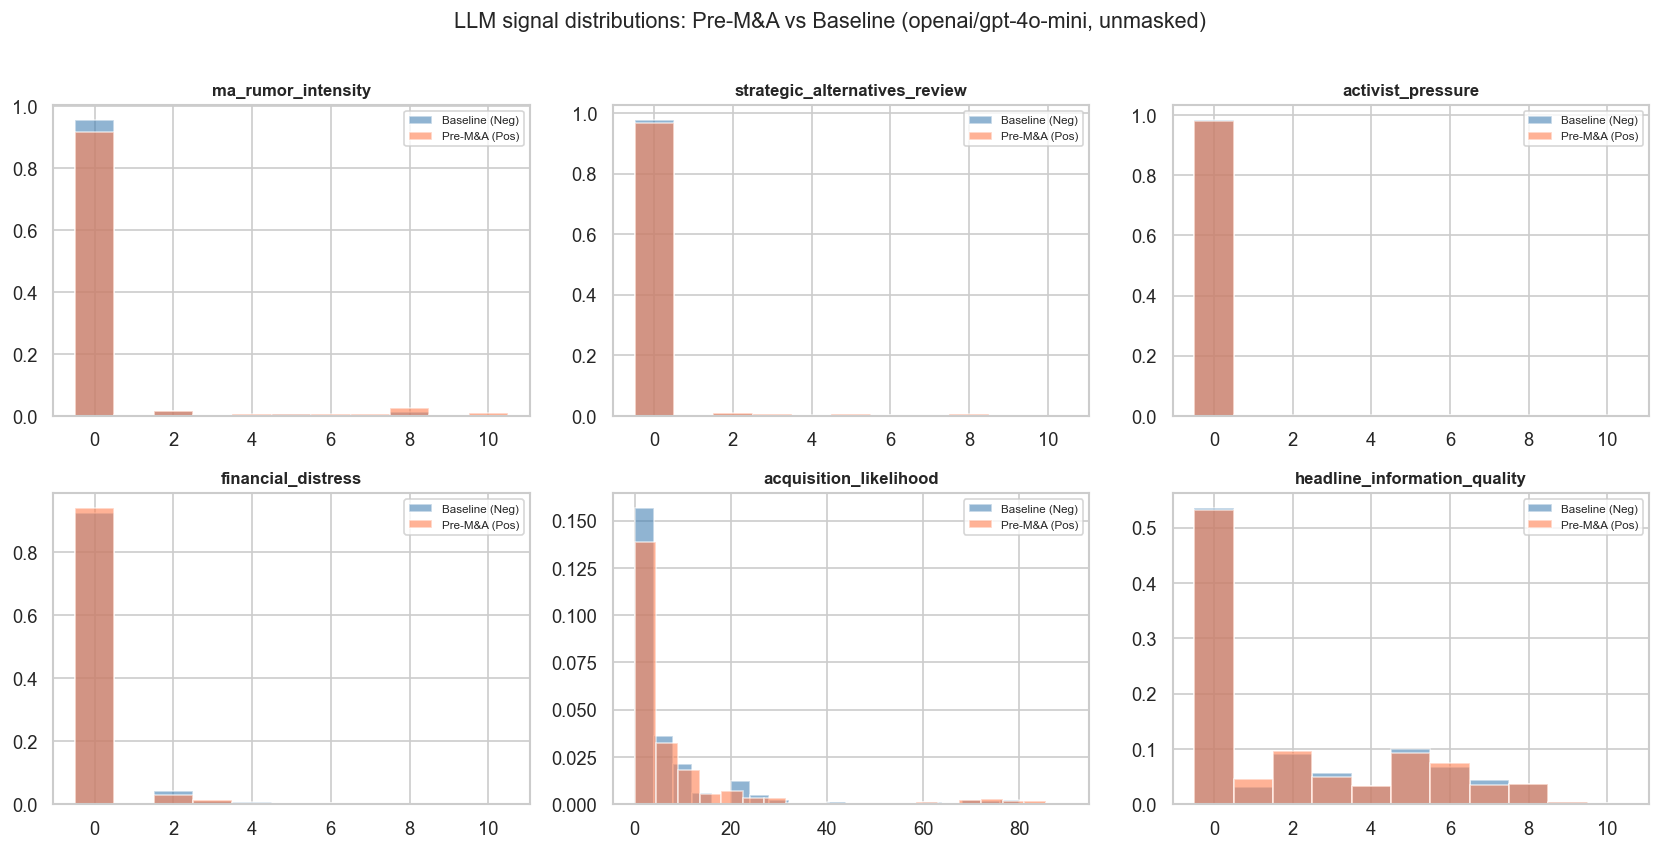

In [27]:
# Overlay pre vs baseline histograms for the key LLM signals
show = ['llm_ma_rumor_intensity', 'llm_strategic_alternatives_review', 'llm_activist_pressure',
        'llm_financial_distress', 'llm_acquisition_likelihood', 'llm_headline_information_quality']
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, feat in zip(axes.flatten(), show):
    for lbl, color, name in [(0, 'steelblue', 'Baseline (Neg)'), (1, 'coral', 'Pre-M&A (Pos)')]:
        d = llm_main[llm_main.label_int == lbl][feat].dropna()
        bins = np.arange(-0.5, 11.5, 1) if feat != 'llm_acquisition_likelihood' else 20
        ax.hist(d, bins=bins, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(feat.replace('llm_', ''), fontweight='bold', fontsize=10)
    ax.legend(fontsize=7)
plt.suptitle('LLM signal distributions: Pre-M&A vs Baseline (openai/gpt-4o-mini, unmasked)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig_llm_distributions.png', dpi=200, bbox_inches='tight')
plt.show()

### A3. Paired Wilcoxon significance
Per-field paired test on the matched pre/baseline design.

In [28]:
# ── Paired Wilcoxon on every LLM field (week4 cell-35 pattern) ──────────────
# For each LLM field: paired Wilcoxon (pre vs baseline) + Mann-Whitney
sig_rows = []
for feat in LLM_NUMERIC:
    pos = llm_main[llm_main.label_int == 1][feat].dropna()
    neg = llm_main[llm_main.label_int == 0][feat].dropna()
    pval_u = np.nan
    if len(pos) > 5 and len(neg) > 5:
        _, pval_u = scipy_stats.mannwhitneyu(pos, neg, alternative='two-sided')
    wide = llm_main.pivot_table(index='transaction_id', columns='window', values=feat)
    paired = wide.dropna(subset=['pre', 'baseline']) if {'pre', 'baseline'}.issubset(wide.columns) else wide.iloc[0:0]
    diff = paired['pre'] - paired['baseline'] if len(paired) else pd.Series(dtype=float)
    pval_w = np.nan
    if (diff != 0).sum() > 5:
        _, pval_w = scipy_stats.wilcoxon(diff)
    sig_rows.append(dict(feature=feat, pre_mean=pos.mean(), baseline_mean=neg.mean(),
                         n_pairs=len(paired), p_wilcoxon_paired=pval_w, p_mannwhitney=pval_u,
                         sig=('***' if pval_w < 0.001 else '**' if pval_w < 0.01 else
                              '*' if pval_w < 0.05 else 'ns') if pd.notna(pval_w) else 'n/a'))
# Rank the fields by paired p-value
sig_df = pd.DataFrame(sig_rows).sort_values('p_wilcoxon_paired')
print('LLM feature significance — paired Wilcoxon (correct for the matched design):')
print(sig_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
# Record which fields (if any) separate the windows
DECK['llm_sig_fields'] = sig_df[sig_df.sig.isin(['*', '**', '***'])]['feature'].tolist()

LLM feature significance — paired Wilcoxon (correct for the matched design):
                           feature  pre_mean  baseline_mean  n_pairs  p_wilcoxon_paired  p_mannwhitney sig
            llm_ma_rumor_intensity    0.4966         0.2022      846             0.0003         0.0004 ***
     llm_sector_consolidation_wave    0.3666         0.2554      846             0.0210         0.1604   *
         llm_growth_expansion_tone    1.3324         1.5240      846             0.1427         0.2173  ns
 llm_strategic_alternatives_review    0.1642         0.1011      846             0.1943         0.1411  ns
     llm_divestiture_restructuring    0.1036         0.1338      846             0.2002         0.8670  ns
        llm_management_instability    0.0538         0.0787      846             0.4222         0.6401  ns
  llm_headline_information_quality    2.0293         2.0684      846             0.5504         0.8751  ns
      llm_undervaluation_narrative    0.1388         0.1583      84

### A4. Highest-conviction calls (qualitative)
The top pre-window scores with the model's own evidence quotes.

In [29]:
# ── Qualitative: highest-conviction pre-window calls, with the LLM's evidence ──
# Show the 3 highest-conviction pre-window calls with the LLM's evidence
top = (llm_main[llm_main.window == 'pre']
       .sort_values('llm_acquisition_likelihood', ascending=False).head(3))
for _, r in top.iterrows():
    print('─' * 100)
    print(f"{r.company_name}  |  acquisition_likelihood={r.llm_acquisition_likelihood:.0f}"
          f"  rumor={r.llm_ma_rumor_intensity:.0f}  strategic_alt={r.llm_strategic_alternatives_review:.0f}"
          f"  theme={r.llm_dominant_theme}")
    print(f"  rationale: {r.llm_rationale}")
    for q in json.loads(r.llm_evidence_quotes or '[]'):
        print(f"  evidence:  “{q}”")

────────────────────────────────────────────────────────────────────────────────────────────────────
ANSYS, Inc.  |  acquisition_likelihood=90  rumor=10  strategic_alt=0  theme=ma_speculation
  rationale: The coverage primarily discusses potential acquisition by Synopsys, indicating high likelihood of M&A activity.
  evidence:  “Ansys Shares Climb 17 % After Reports of Possible Sale”
  evidence:  “Synopsys Reportedly in Advanced Talks to Acquire Ansys”
  evidence:  “Ansys explores sale amid takeover interest - sources”
────────────────────────────────────────────────────────────────────────────────────────────────────
Reverse servicing portfolio  |  acquisition_likelihood=90  rumor=10  strategic_alt=0  theme=ma_speculation
  rationale: The headlines indicate a clear intent and confirmed plans for acquisition, leading to a high likelihood of M&A activity.
  evidence:  “Ocwen to purchase Reverse Mortgage Solution assets for $12M”
  evidence:  “PHH Mortgage Buying Reverse Mortgage Solutio

### A5. Post-knowledge-cutoff holdout
Re-report the section-6 AUCs on deals the model cannot have memorized.

In [30]:
# ── 7a(ii). Post-knowledge-cutoff holdout: §6 AUC on events the model cannot remember ──
# Isolate test rows the model cannot have memorized (post knowledge-cutoff)
cutoff = pd.Timestamp(MODEL_KNOWLEDGE_CUTOFF[PRIMARY_MODEL])
post_mask = test['announcement_date'] >= cutoff
y_post = y_test[post_mask.values]
print(f'{PRIMARY_MODEL} knowledge cutoff ≈ {cutoff.date()} -> {post_mask.sum()} of {len(test)} '
      f'test rows are post-cutoff (announcements the model cannot have memorized)')
# Re-report the section-6 AUCs on that memorization-free holdout
if post_mask.sum() >= 20 and len(set(y_post)) > 1:
    rows = []
    for sname in SETS:
        best = max(results[sname], key=lambda m: results[sname][m]['roc_auc'])
        p_post = results[sname][best]['proba'][post_mask.values]
        lo, hi = bootstrap_auc_ci(y_post, p_post)
        rows.append(dict(feature_set=sname, best_model=best,
                         auc_all_test=round(results[sname][best]['roc_auc'], 3),
                         auc_post_cutoff=round(roc_auc_score(y_post, p_post), 3),
                         ci=f'[{lo:.3f}, {hi:.3f}]', n_post=int(post_mask.sum())))
    post_df = pd.DataFrame(rows)
    print(post_df.to_string(index=False))
    DECK['post_cutoff'] = post_df.to_dict('records')
else:
    print('Too few post-cutoff test rows for a meaningful AUC — flagged as a limitation.')
    DECK['post_cutoff'] = []

openai/gpt-4o-mini knowledge cutoff ≈ 2023-10-01 -> 400 of 400 test rows are post-cutoff (announcements the model cannot have memorized)


           feature_set          best_model  auc_all_test  auc_post_cutoff             ci  n_post
A: classic NLP (week4) Logistic Regression         0.525            0.525 [0.470, 0.580]     400
   B: LLM signals only Logistic Regression         0.518            0.518 [0.465, 0.571]     400
       C: combined A+B Logistic Regression         0.551            0.551 [0.495, 0.606]     400


### A6. Announcement-week (day-0) detection
The week-4 pivot: LLM features on the announcement window vs quiet periods.

In [31]:
# Announcement-week (day-0) LLM scores, if the cache exists
day0 = ok[(ok.task == 'day0') & (ok.model == PRIMARY_MODEL) & (ok.variant == 'unmasked')]
if len(day0):
    # Detection set: day-0 windows (label 1) vs quiet windows (label 0)
    det_base = llm_main[(llm_main.window == 'baseline') &
                        (llm_main.transaction_id.isin(day0.transaction_id))]
    det = pd.concat([
        day0[['transaction_id'] + LLM_NUMERIC].assign(label=1),
        det_base[['transaction_id'] + LLM_NUMERIC].assign(label=0),
    ], ignore_index=True).merge(events[['transaction_id', 'announcement_date']], on='transaction_id')
    # Time-split the detection set
    det = det.sort_values('announcement_date')
    d_split = det['announcement_date'].quantile(0.80)
    dtr, dte = det[det.announcement_date <= d_split], det[det.announcement_date > d_split]
    print(f'Detection dataset: {len(det)} rows ({(det.label == 1).sum()} day-0, '
          f'{(det.label == 0).sum()} baseline) | train {len(dtr)} / test {len(dte)}')
    if len(dte) > 10 and dte.label.nunique() > 1:
        # Train GB; compare LLM detection AUC to week-4's 0.77-0.79
        gb = GradientBoostingClassifier(n_estimators=150, max_depth=2, learning_rate=0.05,
                                        subsample=0.8, random_state=RANDOM_SEED)
        gb.fit(dtr[LLM_NUMERIC].fillna(0), dtr.label)
        p = gb.predict_proba(dte[LLM_NUMERIC].fillna(0))[:, 1]
        lo, hi = bootstrap_auc_ci(dte.label.values, p)
        auc_det = roc_auc_score(dte.label, p)
        print(f'LLM-feature detection test AUC: {auc_det:.3f} [{lo:.3f}, {hi:.3f}]')
        print('Week4 classic-NLP detection reference: 0.773-0.793 (week4 §8)')
        DECK['day0'] = dict(auc=round(float(auc_det), 3), lo=round(lo, 3), hi=round(hi, 3),
                            n=int(len(det)), ref_week4='0.77-0.79')
else:
    print('No day0 LLM scores yet. Run: python code/extract_llm_features.py --task day0\n'
          '(requires data/raw/news/ma_event_news_blackout.csv from diagnose_blackout_signal.py)')

No day0 LLM scores yet. Run: python code/extract_llm_features.py --task day0
(requires data/raw/news/ma_event_news_blackout.csv from diagnose_blackout_signal.py)
